In [1]:
import numpy as np
import pandas as pd

In [3]:
laptop = pd.read_csv('laptop_data.csv')
laptop.head(2)
laptop.drop(columns = ['Unnamed: 0'],inplace = True)
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [5]:
laptop

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [7]:
#
laptop['Ram'] = laptop['Ram'].str.replace('GB','')
laptop['Ram']=laptop['Ram'].astype('int32')

In [9]:
#
laptop['Weight'] = laptop['Weight'].str.replace('kg','')
laptop['Weight']=laptop['Weight'].astype('float32')

In [11]:
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [13]:
# Feature Extraction --> Extracting one column named Touchscreen from ScreenResolution
laptop['ScreenResolution'].value_counts()
laptop['Touchscreen'] = laptop['ScreenResolution'].str.split().apply(lambda x: 1 if 'Touchscreen' in x else 0)

In [15]:
laptop['Touchscreen'].value_counts()

Touchscreen
0    1111
1     192
Name: count, dtype: int64

In [17]:
laptop['IPS'] = laptop['ScreenResolution'].str.split().apply(lambda x: 1 if 'IPS' in x else 0)

In [19]:
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1


In [21]:
new = laptop['ScreenResolution'].str.split('x',n=1,expand=True)

In [23]:
laptop['X_res'] = new[0]
laptop['Y_res'] = new[1]
laptop.sample()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res
898,Dell,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4,1TB HDD,AMD Radeon R5 M420X,Windows 10,2.18,32713.92,0,0,1366,768


In [25]:
laptop['X_res'] = laptop['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

In [27]:
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


In [29]:
laptop['X_res']=laptop['X_res'].astype('int32')
laptop['Y_res']=laptop['Y_res'].astype('int32')
laptop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int32  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float32
 10  Price             1303 non-null   float64
 11  Touchscreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  X_res             1303 non-null   int32  
 14  Y_res             1303 non-null   int32  
dtypes: float32(1), float64(2), int32(3), int64(2), object(7)
memory usage: 132.5+ KB


In [31]:
# Adding new Column as PPI by the help of column X_res,Y_res and Inches
laptop['PPI'] = ((laptop['X_res']**2) + (laptop['Y_res']**2))**0.5 / laptop['Inches']
laptop['PPI'].astype('float32')

0       226.983002
1       127.677940
2       141.212006
3       220.534622
4       226.983002
           ...    
1298    157.350510
1299    276.053528
1300    111.935204
1301    100.454666
1302    100.454666
Name: PPI, Length: 1303, dtype: float32

In [33]:
laptop.drop(columns=['ScreenResolution'],inplace = True)

In [35]:
laptop.head()
laptop.drop(columns=['Inches','X_res','Y_res'],inplace = True)

In [37]:
laptop.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005


In [39]:
laptop['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      146
Intel Core i7 7500U 2.7GHz       134
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core M M3-6Y30 0.9GHz        1
AMD A9-Series 9420 2.9GHz          1
Intel Core i3 6006U 2.2GHz         1
AMD A6-Series 7310 2GHz            1
Intel Xeon E3-1535M v6 3.1GHz      1
Name: count, Length: 118, dtype: int64

In [41]:
laptop['Cpu Name'] = laptop['Cpu'].apply(lambda x: ' '.join(x.split()[:3]))

In [43]:
laptop.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [45]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
       return text
    else:
       if text.split()[0] == 'Intel':
           return 'Other Intel Processor'
       else:
           return 'AMD Processor'

In [47]:
laptop['Cpu Brand'] = laptop['Cpu Name'].apply(fetch_processor)

In [48]:
laptop.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu Name,Cpu Brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5


In [51]:
laptop['Cpu Brand'].value_counts()

Cpu Brand
Intel Core i7            527
Intel Core i5            423
Other Intel Processor    154
Intel Core i3            136
AMD Processor             63
Name: count, dtype: int64

In [53]:
laptop['Memory'].value_counts()

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [61]:
laptop['Memory'] = laptop['Memory'].astype(str).replace('\.0','',regex=True)
laptop['Memory'] = laptop['Memory'].str.replace('GB','')
laptop['Memory'] = laptop['Memory'].str.replace('TB','000')
new = laptop['Memory'].str.split("+",n=1,expand=True)

laptop['first'] = new[0]
laptop['first'] = laptop['first'].str.strip()
laptop['second'] = new[1]
laptop['Layer1HDD'] = laptop['first'].apply(lambda x: 1 if "HDD" in x else 0)
laptop['Layer1SSD'] = laptop['first'].apply(lambda x: 1 if "SSD" in x else 0)
laptop['Layer1Hybrid'] = laptop['first'].apply(lambda x: 1 if "Hybrid" in x else 0)
laptop['Layer1Flash_Storage'] = laptop['first'].apply(lambda x: 1 if "Flash Storage" in x else 0)

laptop['first']= laptop['first'].str.replace(r'\D','',regex=True)

laptop['second'].fillna("0",inplace = True)
laptop['Layer2HDD'] = laptop['second'].apply(lambda x: 1 if "HDD" in x else 0)
laptop['Layer2SSD'] = laptop['second'].apply(lambda x: 1 if "SDD" in x else 0)
laptop['Layer2Hybrid'] = laptop['second'].apply(lambda x: 1 if "Hybrid" in x else 0)
laptop['Layer2Flash_Storage'] = laptop['second'].apply(lambda x: 1 if "Flash Storage" in x else 0)

laptop['second']= laptop['second'].str.replace(r'\D','',regex = True)
laptop['first']=laptop['first'].astype(int)
laptop['second']=laptop['second'].astype(int)
laptop['HDD'] = laptop['first']*laptop['Layer1HDD'] + laptop['second'] * laptop['Layer2HDD']
laptop['SSD'] = laptop['first']*laptop['Layer1SSD'] + laptop['second'] * laptop['Layer2SSD']
laptop['Hybrid'] = laptop['first']*laptop['Layer1Hybrid'] + laptop['second'] * laptop['Layer2Hybrid']
laptop['Flash_Storage'] = laptop['first']*laptop['Layer1Flash_Storage'] + laptop['second'] * laptop['Layer2Flash_Storage']

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\bikes\AppData\Local\Temp\ipykernel_26400\768030643.py:1: SyntaxWarning: invalid escape sequence '\.'
  laptop['Memory'] = laptop['Memory'].astype(str).replace('\.0','',regex=True)
C:\Users\bikes\AppData\Local\Temp\ipykernel_26400\768030643.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  laptop['second'].fillna("0",inplace = True)


In [63]:
laptop.drop(columns=['first','second','Layer1HDD','Layer1SSD','Layer1Hybrid','Layer1Flash_Storage',
                    'Layer2HDD','Layer2SSD','Layer2Hybrid','Layer2Flash_Storage'],inplace = True)

In [65]:
laptop.drop(columns = ['Layer2SDD'],inplace = True)

KeyError: "['Layer2SDD'] not found in axis"

In [67]:
laptop.sample(4)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu Name,Cpu Brand,HDD,SSD,Hybrid,Flash_Storage
1218,Lenovo,Gaming,Intel Core i7 6700HQ 2.6GHz,8,128 SSD + 1000 HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.60,67772.1600,0,1,141.211998,Intel Core i7,Intel Core i7,1000,128,0,0
1024,Dell,Notebook,Intel Core i5 6300U 2.4GHz,8,500 HDD,Intel HD Graphics 520,Windows 10,2.09,55754.3232,0,0,141.211998,Intel Core i5,Intel Core i5,500,0,0,0
416,Dell,Notebook,Intel Core i3 6006U 2GHz,4,128 SSD,Intel HD Graphics 520,Windows 10,1.65,36709.9200,0,0,117.826530,Intel Core i3,Intel Core i3,0,128,0,0
1207,Lenovo,Notebook,AMD E-Series 9000 2.2GHz,4,500 HDD,AMD Radeon R2 Graphics,Windows 10,2.20,15930.7200,0,0,100.454670,AMD E-Series 9000,AMD Processor,500,0,0,0


In [69]:
laptop.drop(columns = ['Memory'],inplace = True)

In [71]:
laptop.head()

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu Name,Cpu Brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5,0,0,0,128
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5,0,256,0,0


In [75]:
laptop.corr(numeric_only=True)['Price']

Ram              0.743007
Weight           0.210370
Price            1.000000
Touchscreen      0.191226
IPS              0.252208
PPI              0.473487
HDD             -0.096441
SSD              0.676202
Hybrid           0.007989
Flash_Storage   -0.040511
Name: Price, dtype: float64

In [77]:
laptop.drop(columns = ['Hybrid','Flash_Storage'],inplace = True)

In [79]:
laptop.head()

,Company,TypeName,Cpu,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu Name,Cpu Brand,HDD,SSD
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5,0,128
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5,0,0
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5,0,256
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7,0,512
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5,0,256


In [81]:
laptop['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
AMD Radeon R5 520            1
AMD Radeon R7                1
Intel HD Graphics 540        1
AMD Radeon 540               1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [83]:
laptop['Gpu Brand'] = laptop['Gpu'].apply(lambda x: x.split()[0])

In [85]:
laptop = laptop[laptop['Gpu Brand'] != 'ARM']

In [87]:
laptop['Gpu Brand'].value_counts()

Gpu Brand
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

In [89]:
laptop.drop(columns = ['Gpu'],inplace = True)

C:\Users\bikes\AppData\Local\Temp\ipykernel_26400\1379380167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laptop.drop(columns = ['Gpu'],inplace = True)


In [91]:
laptop.head()

,Company,TypeName,Cpu,Ram,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu Name,Cpu Brand,HDD,SSD,Gpu Brand
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5,0,0,Intel
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5,0,256,Intel


In [93]:
laptop['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [95]:
def catego_os(text):
    if text == 'Windows 10' or text == 'Windows 7' or text == 'Windows 10 S':
       return 'Windows'
    elif text == 'macOS' or text == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/ Linux'

In [97]:
laptop['os'] = laptop['OpSys'].apply(catego_os)

C:\Users\bikes\AppData\Local\Temp\ipykernel_26400\2843346033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laptop['os'] = laptop['OpSys'].apply(catego_os)


In [99]:
laptop.sample(5)

,Company,TypeName,Cpu,Ram,OpSys,Weight,Price,Touchscreen,IPS,PPI,Cpu Name,Cpu Brand,HDD,SSD,Gpu Brand,os
493,Acer,Notebook,AMD A10-Series 9620P 2.5GHz,8,Windows 10,2.20,30849.1200,0,0,100.454670,AMD A10-Series 9620P,AMD Processor,1000,0,AMD,Windows
1154,Dell,Notebook,Intel Core i5 6300HQ 2.3GHz,8,Windows 10,2.04,119916.2304,1,1,282.423996,Intel Core i5,Intel Core i5,0,256,Nvidia,Windows
442,Lenovo,Ultrabook,Intel Core i5 7200U 2.5GHz,8,Windows 10,1.36,76137.1200,0,1,176.232574,Intel Core i5,Intel Core i5,0,256,Intel,Windows
315,Dell,Notebook,Intel Core i5 8250U 1.6GHz,8,Windows 10,2.33,44968.3200,0,0,141.211998,Intel Core i5,Intel Core i5,1000,128,AMD,Windows
1103,HP,Workstation,Intel Core i7 6700HQ 2.6GHz,8,Windows 7,3.00,154458.7200,0,1,127.335675,Intel Core i7,Intel Core i7,1000,0,AMD,Windows


In [101]:
laptop.drop(columns = ['OpSys'],inplace = True)

C:\Users\bikes\AppData\Local\Temp\ipykernel_26400\384473840.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laptop.drop(columns = ['OpSys'],inplace = True)


In [103]:
laptop.head()

,Company,TypeName,Cpu,Ram,Weight,Price,Touchscreen,IPS,PPI,Cpu Name,Cpu Brand,HDD,SSD,Gpu Brand,os
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5,0,256,Intel,Others/No OS/ Linux
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5,0,256,Intel,Mac


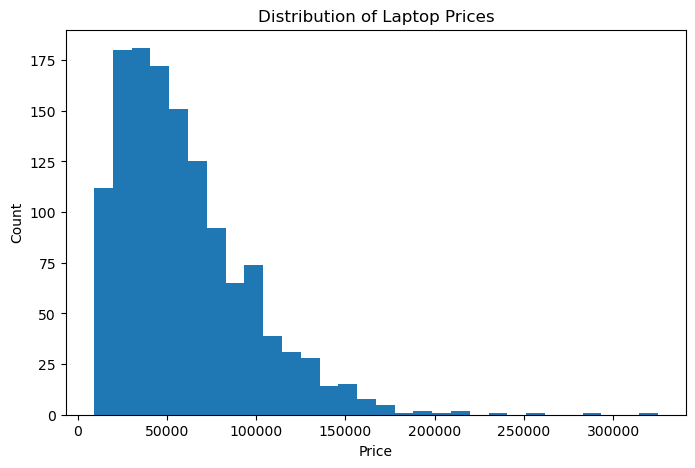

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(laptop['Price'], bins=30)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

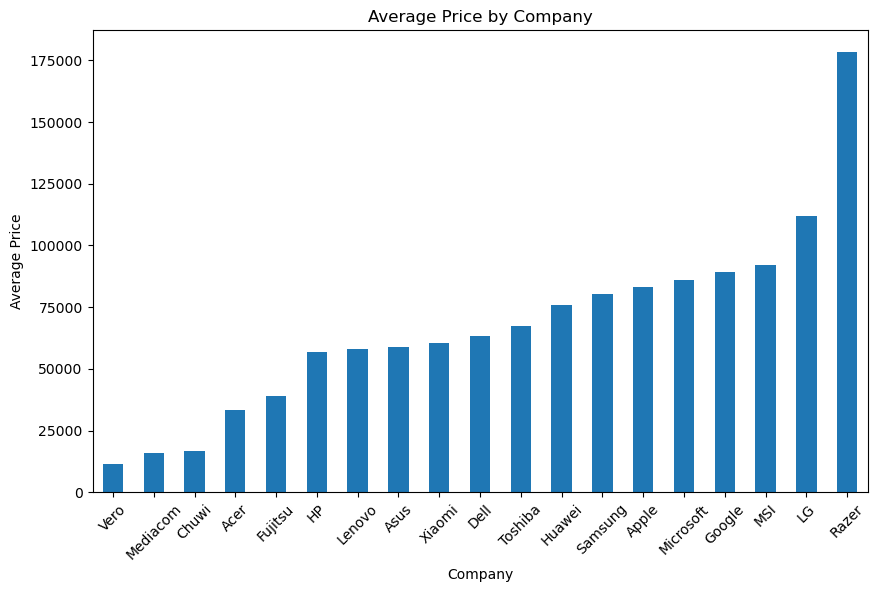

In [107]:


company_price = laptop.groupby('Company')['Price'].mean().sort_values()

plt.figure(figsize=(10,6))
company_price.plot(kind='bar')
plt.title("Average Price by Company")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

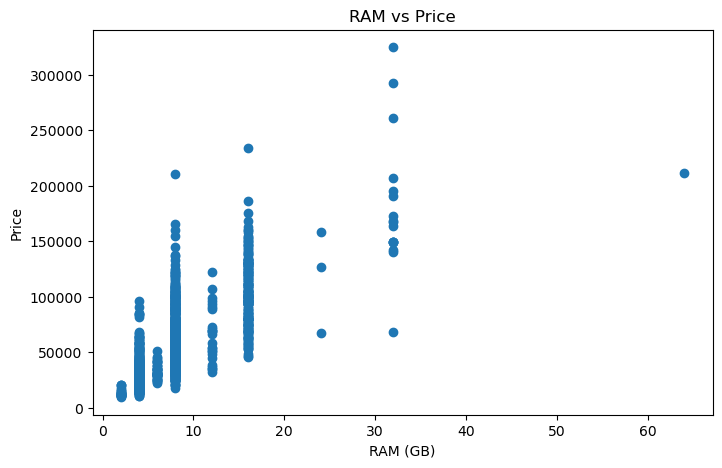

In [109]:
plt.figure(figsize=(8,5))
plt.scatter(laptop['Ram'], laptop['Price'])
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.title("RAM vs Price")
plt.show()

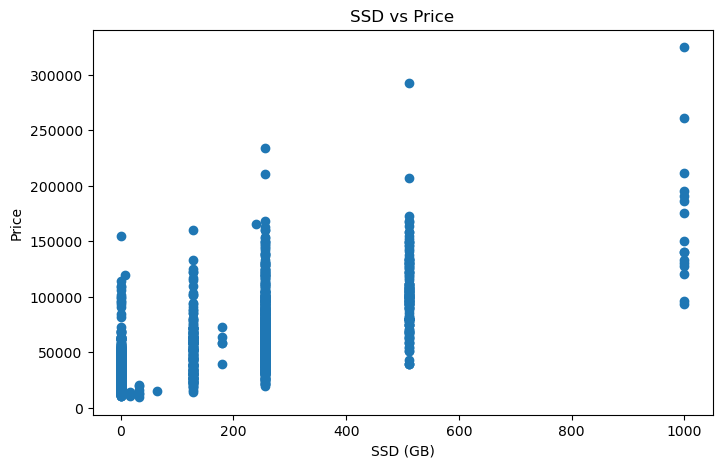

In [111]:
plt.figure(figsize=(8,5))
plt.scatter(laptop['SSD'], laptop['Price'])
plt.xlabel("SSD (GB)")
plt.ylabel("Price")
plt.title("SSD vs Price")
plt.show()

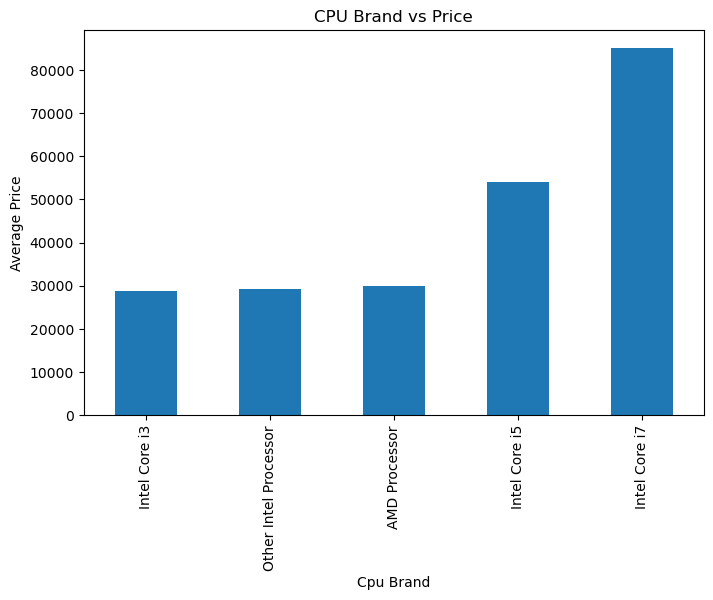

In [113]:
cpu_price = laptop.groupby('Cpu Brand')['Price'].mean().sort_values()

plt.figure(figsize=(8,5))
cpu_price.plot(kind='bar')
plt.ylabel("Average Price")
plt.title("CPU Brand vs Price")
plt.show()

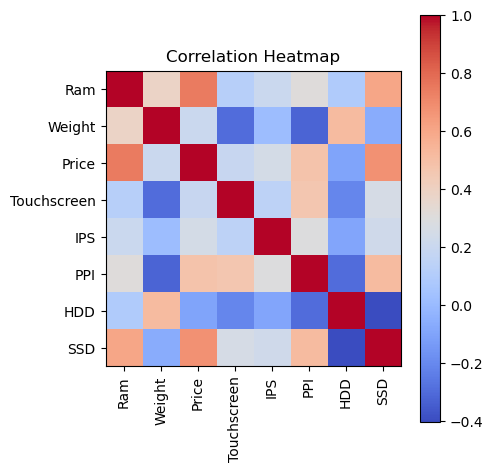

In [115]:

corr = laptop.select_dtypes(include='number').corr()

plt.figure(figsize=(5,5))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

C:\Users\bikes\AppData\Local\Temp\ipykernel_26400\957733346.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(laptop['Price'])


<Axes: xlabel='Price', ylabel='Density'>

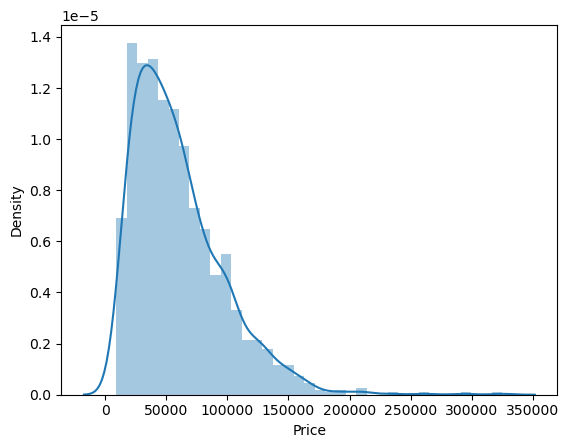

In [117]:
import seaborn as sns
sns.distplot(laptop['Price'])

C:\Users\bikes\AppData\Local\Temp\ipykernel_26400\3984844542.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(laptop['Price']))


<Axes: xlabel='Price', ylabel='Density'>

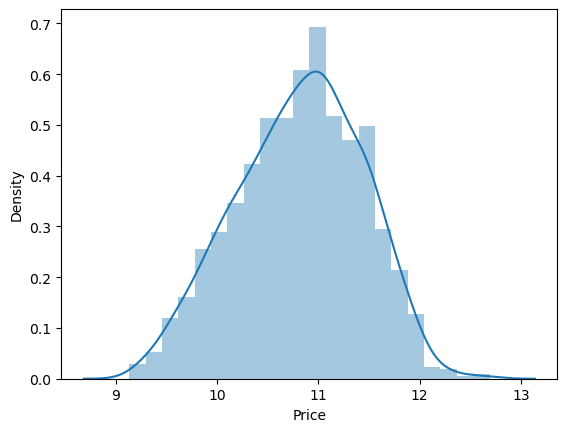

In [118]:
sns.distplot(np.log(laptop['Price']))

In [121]:
laptop.drop(columns = ['Cpu','Cpu Name'],inplace = True)

C:\Users\bikes\AppData\Local\Temp\ipykernel_26400\4147928651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  laptop.drop(columns = ['Cpu','Cpu Name'],inplace = True)


In [123]:
X = laptop.drop(columns = ['Price'])
y = np.log(laptop['Price'])
X.head()

,Company,TypeName,Ram,Weight,Touchscreen,IPS,PPI,Cpu Brand,HDD,SSD,Gpu Brand,os
0,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/ Linux
3,Apple,Ultrabook,16,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [125]:
y.head()

0    11.175755
1    10.776777
2    10.329931
3    11.814476
4    11.473101
Name: Price, dtype: float64

In [127]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.5, random_state = 2)

In [129]:
X_train

,Company,TypeName,Ram,Weight,Touchscreen,IPS,PPI,Cpu Brand,HDD,SSD,Gpu Brand,os
304,Asus,Gaming,8,2.50,0,0,141.211998,Intel Core i7,1000,128,Nvidia,Windows
36,Acer,Notebook,4,2.10,0,0,100.454670,Intel Core i3,1000,0,Intel,Others/No OS/ Linux
42,Asus,Notebook,8,2.30,0,0,100.454670,Intel Core i5,1000,0,Nvidia,Others/No OS/ Linux
675,MSI,Gaming,16,2.40,0,0,141.211998,Intel Core i7,1000,256,Nvidia,Windows
1025,HP,Ultrabook,4,1.26,0,0,125.367428,Intel Core i5,0,256,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...
466,Acer,Notebook,4,2.20,0,0,100.454670,Intel Core i3,500,0,Nvidia,Windows
299,Asus,Ultrabook,16,1.63,0,0,141.211998,Intel Core i7,0,512,Nvidia,Windows
493,Acer,Notebook,8,2.20,0,0,100.454670,AMD Processor,1000,0,AMD,Windows
527,Lenovo,Notebook,8,2.20,0,0,100.454670,Intel Core i3,2000,0,Nvidia,Others/No OS/ Linux


In [131]:
X_test

,Company,TypeName,Ram,Weight,Touchscreen,IPS,PPI,Cpu Brand,HDD,SSD,Gpu Brand,os
248,HP,Notebook,4,1.49,0,1,165.632118,Intel Core i5,500,0,Intel,Windows
555,Asus,Notebook,4,2.00,0,0,100.454670,Other Intel Processor,500,0,Intel,Others/No OS/ Linux
1251,HP,Notebook,4,1.86,0,0,100.454670,AMD Processor,500,0,AMD,Windows
547,Lenovo,Notebook,4,2.15,0,0,141.211998,Intel Core i5,1000,0,Intel,Others/No OS/ Linux
885,HP,2 in 1 Convertible,4,1.28,1,0,165.632118,Intel Core i5,0,256,Intel,Windows
...,...,...,...,...,...,...,...,...,...,...,...,...
669,Acer,Notebook,4,2.10,0,0,100.454670,Intel Core i3,0,128,Intel,Others/No OS/ Linux
644,Acer,Notebook,4,2.40,0,0,100.454670,Intel Core i3,500,0,Intel,Windows
340,Dell,Notebook,4,2.20,0,0,100.454670,Other Intel Processor,500,0,Intel,Others/No OS/ Linux
346,HP,Notebook,2,1.44,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows


In [133]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [141]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor


## Linear Regression

In [143]:
step1 = ColumnTransformer(
    transformers = [
        ('col_tnf',
        OneHotEncoder(sparse_output = False, drop ='first',handle_unknown='ignore'),
         [0,1,7,10,11]
        )],
    remainder = 'passthrough'
)
step2 = LinearRegression()

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)
print('R2 Score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 Score 0.8065203986410978
MAE 0.21201659255800873


C:\Users\bikes\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## KNN

In [158]:
step1 = ColumnTransformer(
    transformers = [
        ('col_tnf',
        OneHotEncoder(sparse_output = False, drop ='first',handle_unknown='ignore'),
         [0,1,7,10,11]
        )],
    remainder = 'passthrough'
)

step2 = KNeighborsRegressor(n_neighbors=4)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)

print('R2 Score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))


R2 Score 0.7504387195342775
MAE 0.22442168691268602


C:\Users\bikes\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Decision Tree

In [174]:
step1 = ColumnTransformer(
    transformers = [
        ('col_tnf',
        OneHotEncoder(sparse_output = False, drop ='first',handle_unknown='ignore'),
         [0,1,7,10,11]
        )],
    remainder = 'passthrough'
)

step2 = DecisionTreeRegressor(max_depth = 7)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])
pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)

print('R2 Score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))


R2 Score 0.8020667215695583
MAE 0.213552148985526


C:\Users\bikes\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [178]:
import pickle
pickle.dump(laptop,open('df.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))

In [180]:
laptop.head()

,Company,TypeName,Ram,Weight,Price,Touchscreen,IPS,PPI,Cpu Brand,HDD,SSD,Gpu Brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/ Linux
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel,Mac
